# Homework 11: Evaluation & Risk Communication
Bootstrap uncertainty, scenario sensitivity, and subgroup diagnostics for the Stage 10b classifier.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
P=Path.cwd().resolve(); P=P if P.name=='homework11' else P/'homework'/'homework11'; sys.path.insert(0,str(P))
from src.evaluation import bootstrap_metric,classification_metrics
df=pd.read_csv(P.parent/'homework09/data/processed/aapl_features.csv',parse_dates=['date']).sort_values('date'); features=['return_lag1','rolling_mean_5','rolling_std_10','momentum_5']+[c for c in df if c.startswith('dow_')]; df['y_up']=(df.target_next_return>0).astype(int); cut=int(len(df)*.75); tr,te=df.iloc[:cut],df.iloc[cut:]

In [2]:
def fit_scenario(class_weight=None):
    m=Pipeline([('scale',StandardScaler()),('logit',LogisticRegression(max_iter=1000,class_weight=class_weight,random_state=5040))]); m.fit(tr[features],tr.y_up); p=m.predict(te[features]); return m,p,classification_metrics(te.y_up,p)
base,p_base,m_base=fit_scenario(); balanced,p_bal,m_bal=fit_scenario('balanced'); pd.DataFrame({'baseline':m_base,'balanced':m_bal}).T

,accuracy,precision,recall,f1
baseline,0.566667,0.557692,0.90625,0.690476
balanced,0.516667,0.531915,0.78125,0.632911


Baseline accuracy=0.567; bootstrap 95% CI=(0.433, 0.700)


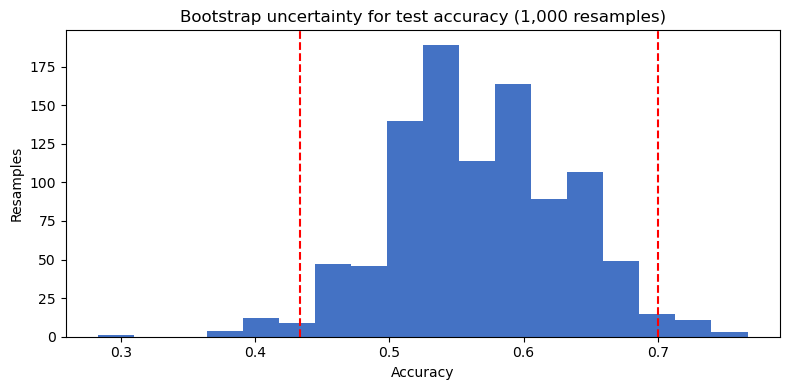

In [3]:
boot,ci=bootstrap_metric(te.y_up.to_numpy(),p_base,lambda a,b:(a==b).mean(),n_boot=1000,seed=5040)
print(f'Baseline accuracy={m_base["accuracy"]:.3f}; bootstrap 95% CI=({ci[0]:.3f}, {ci[1]:.3f})')
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(boot,bins=18,color='#4472C4'); ax.axvline(ci[0],color='red',ls='--'); ax.axvline(ci[1],color='red',ls='--'); ax.set(title='Bootstrap uncertainty for test accuracy (1,000 resamples)',xlabel='Accuracy',ylabel='Resamples'); plt.tight_layout(); plt.show()

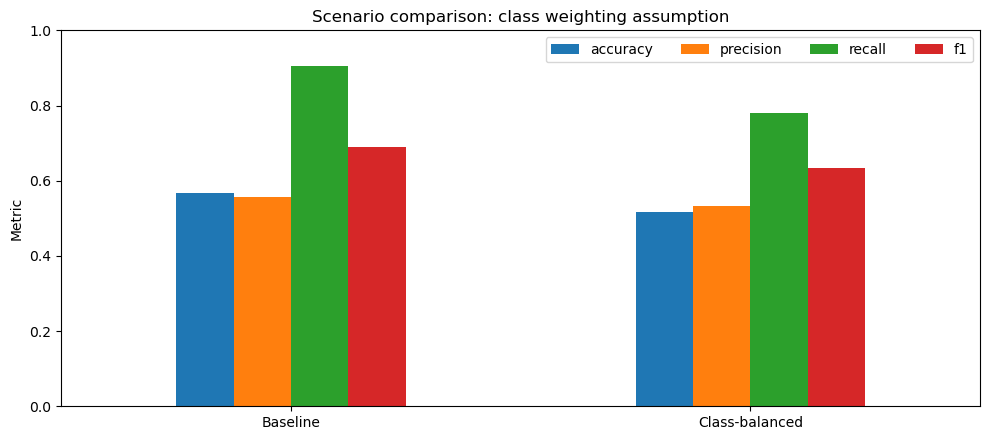

In [4]:
scenarios=pd.DataFrame({'Baseline':m_base,'Class-balanced':m_bal}).T; ax=scenarios[['accuracy','precision','recall','f1']].plot.bar(figsize=(10,4.5)); ax.set(title='Scenario comparison: class weighting assumption',ylabel='Metric',ylim=(0,1)); ax.tick_params(axis='x',rotation=0); ax.legend(ncol=4); plt.tight_layout(); plt.show()

,accuracy,precision,recall,f1
volatility_group,,,,
Lower volatility,0.500000,0.48000,0.857143,0.615385
Higher volatility,0.633333,0.62963,0.944444,0.755556


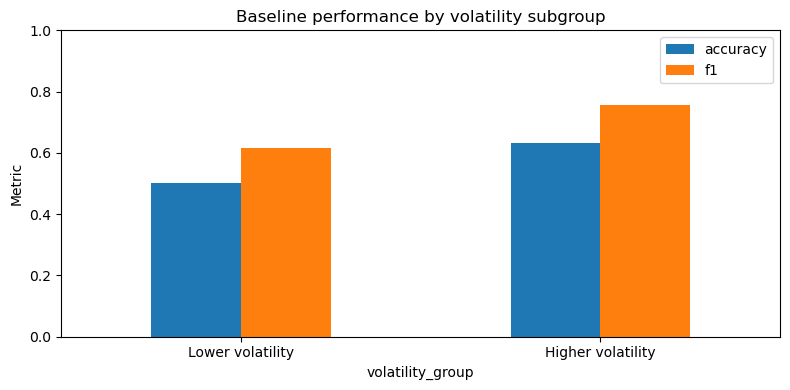

In [5]:
te=te.copy(); te['prediction']=p_base; te['volatility_group']=pd.qcut(te['rolling_std_10'],2,labels=['Lower volatility','Higher volatility']); subgroup=te.groupby('volatility_group',observed=True).apply(lambda g: pd.Series(classification_metrics(g.y_up,g.prediction)),include_groups=False); display(subgroup); ax=subgroup[['accuracy','f1']].plot.bar(figsize=(8,4)); ax.set(title='Baseline performance by volatility subgroup',ylabel='Metric',ylim=(0,1)); ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()

## Stakeholder summary
The direction signal is uncertain: the bootstrap interval shows the range of accuracy compatible with this small holdout, so the point estimate should not be presented as guaranteed performance. Results **hold only if** the next market period resembles the training year and feature timing remains strictly past-only. Class balancing changes recall and precision, demonstrating sensitivity to the cost assigned to missed up-days versus false alerts.

Performance differences between lower- and higher-volatility days reveal where reliability may weaken; subgroup samples are small, so the gap itself is uncertain. Key risks are regime change, repeated time observations violating the independent-resample assumption, transaction costs, and one-ticker selection. Before action, use a longer rolling backtest, block bootstrap for time dependence, explicit trading costs, and monitoring by volatility regime. The model is suitable as a learning benchmark, not as a stand-alone investment rule.